Created by Angelo Orletti Del Rey for its masters in psychiatry at Unifesp - SP - Brasil

It was based in our groups previeous works in cotical striatal connectivity in INPD data base of fmri

In [1]:
import numpy as np
import os, sys
import bids
import nibabel as nib
# from scipy.stats import pearsonr
from scipy.stats import chi2
import statsmodels.api as sm
import statsmodels.formula.api as smf
# from statsmodels.genmod.families import NegativeBinomial
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import matplotlib.pyplot as plt

import argparse
import pandas as pd

from sklearn.preprocessing import StandardScaler

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
# from scipy.linalg import LinAlgError

# Suppress convergence warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")


In [2]:
def parse():

        options = argparse.ArgumentParser(description="Run 1st level analysis. Created by ...")
        options.add_argument('-p', '--participants', nargs='+',dest="participants", action='store', type=str, required=False,
                            help='id of subject or list of subjects')
        options.set_defaults(participants=None)
        options.add_argument('-w', '--workdir',dest="workdir", action='store', type=str, required=False,
                            help='the work directory for the project')
        options.set_defaults(workdir=os.environ["ROOTDIR"])
        options.add_argument('-b', '--bidsdir',dest="rawdata", action='store', type=str, required=False,
                            help='the work directory for the project')
        options.set_defaults(rawdata=os.path.join(os.environ["ROOTDIR"],"BIDS"))
        options.add_argument('-d', '--derivatives',dest="derivatives", action='store', type=str, required=True,
                            help='path to fMRIprep directory')
        options.add_argument('-o', '--outputs',dest="output", action='store', type=str, required=True,
                            help='path to fMRIprep directory')
        #print(options.parse_args())

        return options.parse_args()

os.environ["ROOTDIR"] = r'D://'   # seth path
rootdir = os.environ["ROOTDIR"]
if hasattr(sys, "ps1"):
    options = {}
    workdir = os.environ["ROOTDIR"]
    firstleveldir  = os.path.join(workdir,"BIDS","derivatives","first_level_results")
    demographic = os.path.join(workdir,"metadata")
    confounds = os.path.join(workdir,"metadata")
    output = os.path.join(workdir,'second_level_results')
    participants = []

else :
    options = parse()
    participants = options.participants
    workdir = options.workdir
    rawdata = options.rawdata
    derivat = options.derivatives
    output  = options.outputs

print('firstlevel: ', firstleveldir)
    
bidslayout = bids.BIDSLayout(firstleveldir, validate = False) #With validate = True it doesn't find any subjects

if not participants:
    participants = bidslayout.get_subjects() #take all subjects
    #participants_sub = ["sub-" + item for item in participants]

seednames = ['DCPutamen',
            'DorsalCaudate',
            'DRPutamen',
            'InfVentralCaudate',
            'SupVentralCaudate',
            'VRPutamen'
            ]

tmap_allsubj = [] #initialize array for tmaps

print("Loading tmaps for all participants...")
for p in participants:
    #print(f"Subject: {p}")
    p = p.replace("sub-", "")

    # for ses in bidslayout.get_sessions(subject=p):
    #     #print(f"Session: {ses}")                
    
    ses = '1'

    for r in bidslayout.get_runs(subject=p, session=ses):
        #print(f"Run: {r}")

        tmap_metadata = {
            'task': 'rest',
            'suffix': 'tstat',
            'extension': '.txt',
            'run': str(r),
            'session': str(ses),
            'subject': 'sub-'+p,
            'space': 'MNI152NLin2009cAsym',
            'seed': 'SeedtoROI'
        }

        # Save each tmap as a nifti file
        filepath = os.path.join(firstleveldir,tmap_metadata["subject"],"ses-"+tmap_metadata['session'],"func")
        filename = tmap_metadata["subject"] + "_" + \
                    "ses-"+tmap_metadata['session'] + "_" + \
                    "task-"+tmap_metadata['task'] + "_" + \
                    "run-"+tmap_metadata['run'] + "_" + \
                    "space-"+tmap_metadata['space'] + "_" + \
                    "seed-"+tmap_metadata['seed'] + "_" + \
                    tmap_metadata["suffix"] + \
                    tmap_metadata["extension"]
        tmap_path = os.path.join(filepath, filename)

        #load the tmaps for each subject and then append to the tmap_allsubj array
        tmap = pd.read_csv(tmap_path, delimiter=' ', header=None, skiprows=1) #also skips the first row
        tmap.columns = seednames
        tmap_allsubj.append(tmap)

#load socioeconomic and psichometric data for all subjects
print("Loading socioeconomic and psichometric data for all participants...")
socio_psi=pd.read_csv(os.path.join(demographic,'variaveis_analise_conf_nova-exclusão.tsv'), sep='\t')
#substitute in age colunm , to . for decimals if necessary and convert to float
# socio_psi['age'] = socio_psi['age'].str.replace(',', '.').astype(float)

# organinzing the tmaps. Joining the columns of the tmaps for all subjects. So for each subject
# we have to join the first collunm of the first tmap with the first column of the second tmap and so on
# and then join the second column of the first tmap with the second column of the second tmap and so on
# and so on
print("Organizing tmaps...")
tmap_allsubj = pd.concat(tmap_allsubj, axis=1)
tmap_allsubj_organized = {}

for seed in seednames:
    #drop columns with names different from seednames[i]
    tmap_allsubj_organized[seed] = tmap_allsubj.drop(columns=[col for col in tmap_allsubj.columns if col != seed])

# What do we have now: tmap_allsubj_organized is a dictionary with keys being the seednames and values being
# dataframes with the tmaps for all subjects for that seed. This have dimensions of n_ROIs x n_subjects
# Now we have to transpose it to get the data in the format n_subjects x n_ROIs and then join with the
# socioeconomic and psichometric data
# Also, we have to add the sub_id column to the conectivity data to be able to join with the socioeconomic
# and psichometric data
subs = {'sub_id': []}
for p in participants:
    ses = '1'
    if bidslayout.get_runs(subject=p, session=ses) != []:
        subs['sub_id'].append('sub-'+p)

subs = pd.DataFrame(subs)

# create the collunms names for the data frame of rois
roi_names = [f'roi_{i}' for i in range(101)]

for seed in seednames:
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].transpose()
    tmap_allsubj_organized[seed].columns = roi_names
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].reset_index().join(subs, how='inner')
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].drop(columns=['index'])

# Now we have to join the tmaps with the socioeconomic and psichometric data
print("Joining tmaps with socioeconomic and psichometric data...")

for seed in seednames:
    tmap_allsubj_organized[seed] = pd.merge(tmap_allsubj_organized[seed], socio_psi, on='sub_id', how='inner')
    # scaling the data for the regression for the continous variables age, abepscore, cape
    # and for the rois
    # Scale all ROIs
    roi_cols = [f'roi_{i}' for i in range(101)]
    scaler_roi = StandardScaler()
    tmap_allsubj_organized[seed][roi_cols] = scaler_roi.fit_transform(tmap_allsubj_organized[seed][roi_cols])
    
    # Scale age and abepscore together
    scaler_demo = StandardScaler()
    tmap_allsubj_organized[seed][['age', 'abepscore']] = scaler_demo.fit_transform(tmap_allsubj_organized[seed][['age', 'abepscore']])
    


firstlevel:  D://BIDS\derivatives\first_level_results
Loading tmaps for all participants...
Loading socioeconomic and psichometric data for all participants...
Organizing tmaps...
Joining tmaps with socioeconomic and psichometric data...


In [3]:
# plt.hist(tmap_allsubj_organized['DCPutamen']['cape_tot'])

In [4]:
# now we run the regression analysis for each seed. The dependent variable is the connectivity and the independent
# variables are the CAPE scores. The socioeconomic variables are used as confound variables
print("Running regression analysis (salience, CENTRAL EXECUTIVE and default mode network)...")

shaeffer_network = pd.read_csv(os.path.join(demographic, 
    'tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-100Parcels7Networks_dseg.tsv'), delimiter='\t')

# selecting only the rois that belong to the salience network (name with SalVentAttn) 
# or the default mode network (name with Default)
shaeffer_network = shaeffer_network[shaeffer_network['name'].str.contains('SalVentAttn|Default|Cont')]
print("Selected ROIs for analysis:", shaeffer_network['index'].tolist())
print("There are", len(shaeffer_network['index'].tolist()), "rois in the salience, CENTRAL EXECUTIVE and default mode network that will be analyzed")

# running the regression analysis for each roi in the salience network
results_networks = {} 
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    results_networks[cape] = {}
    for seed in seednames:
        results_networks[cape][seed] = {}
        #salience analisys
        for roi in shaeffer_network['index']:

            
            #running the regression analysis
            # With colection_site and selection as a random effect
            model = smf.mixedlm( f'{cape} ~ roi_{roi} + age  + C(gender)  + abepscore + fd_mean_value + C(selection)', 
                                data=tmap_allsubj_organized[seed], 
                                groups=tmap_allsubj_organized[seed]["colection_site"])
            fit = model.fit()

            # Extract desired values
            results_networks[cape][seed][roi] = {
                'coef': fit.params[f'roi_{roi}'],
                'intercept': fit.params['Intercept'],
                't_value': fit.tvalues[f'roi_{roi}'],
                'p_value': fit.pvalues[f'roi_{roi}'],
                # 't-value_selection': fit.tvalues['selection'],
                # 'p-value_selection': fit.pvalues['selection'],
                'AIC': fit.aic,
                'BIC': fit.bic,
                # 'deviance': fit.deviance,
                # 'R_squared_ajusted': fit.rsquared_adj,
                # 'degrees_of_freedom': fit._iweights.sum() - len(fit.params),
                'residuals': fit.resid,
                # 'mcFadden_R_squared': 1 - fit.deviance / fit.null_deviance,
                'log_likelihood': fit.llf
            }
            
            

Running regression analysis (salience, CENTRAL EXECUTIVE and default mode network)...
Selected ROIs for analysis: [24, 25, 26, 27, 28, 29, 30, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 74, 75, 76, 77, 78, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
There are 49 rois in the salience, CENTRAL EXECUTIVE and default mode network that will be analyzed


In [5]:
# correcting the p-values in two types: 
# first corret to all p-values in each CAPE score (corr_p_val_within_cape).
# second correct to all p-values in the comparison (corr_p_val_general).

from statsmodels.stats.multitest import multipletests
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    print(f'Intra CAPE FDR - {cape}')
    
    pvals = []
    keys = []  # <- guardar correspondência
    
    # coletar p-values + chaves
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            pvals.append(results_networks[cape][seed][roi]['p_value'])
            keys.append((seed, roi))
    
    print(f'Number of p-values to correct for {cape}: {len(pvals)}')

    # correção FDR
    corrected = multipletests(pvals, method='fdr_bh')[1]

    # reatribuir corretamente
    for (seed, roi), corr_p in zip(keys, corrected):
        results_networks[cape][seed][roi]['corr_p_value_within_cape'] = corr_p

        if corr_p <= 0.05:
            print(f"###{cape} seed-{seed} roi-{roi} -> corr_p_val_within_cape {corr_p:.3f} -> Association {results_networks[cape][seed][roi]['coef']:.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f}")

        if corr_p <= 0.10:
            print(f">>>{cape} seed-{seed} roi-{roi} -> corr_p_val_within_cape {corr_p:.3f} -> Association {results_networks[cape][seed][roi]['coef']:.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f}")


print('No FDR Corretion')
# printing the ones that are significant without correcting for all CAPE scores together
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            if results_networks[cape][seed][roi]['p_value'] <= 0.005:
                print(f"### {cape} roi-{roi} -> p_val {results_networks[cape][seed][roi]['p_value']:.3f} -> Association {(results_networks[cape][seed][roi]['coef']):.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f} ")

#printing the top five highest associations for each CAPE score without correcting for all CAPE scores together
print('---Top 5 associations for each CAPE score without general FDR correction---')
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    associations = []
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            associations.append((results_networks[cape][seed][roi]['coef'], cape, seed, roi, results_networks[cape][seed][roi]['p_value'], results_networks[cape][seed][roi]['t_value'], results_networks[cape][seed][roi]['corr_p_value_within_cape']))
    # Sort the associations by absolute value of the coefficient and get the top 5
    top_associations = sorted(associations, key=lambda x: abs(x[0]), reverse=True)[:5]
    print(f"Top 5 associations for {cape}:")
    for assoc in top_associations:
        print(f"### {assoc[1]} seed-{assoc[2]} roi-{assoc[3]} -> coef {assoc[0]:.3f} -> p_val {assoc[4]:.3f} -> t-value {assoc[5]:.3f} -> corr_p_val_within_cape {assoc[6]:.3f} ")


Intra CAPE FDR - cape_tot
Number of p-values to correct for cape_tot: 294
>>>cape_tot seed-DRPutamen roi-44 -> corr_p_val_within_cape 0.079 -> Association -0.887 -> t-value -3.645 
Intra CAPE FDR - cape_PA_score
Number of p-values to correct for cape_PA_score: 294
###cape_PA_score seed-DRPutamen roi-86 -> corr_p_val_within_cape 0.010 -> Association -0.249 -> t-value -4.155 
>>>cape_PA_score seed-DRPutamen roi-86 -> corr_p_val_within_cape 0.010 -> Association -0.249 -> t-value -4.155 
Intra CAPE FDR - cape_PI_score
Number of p-values to correct for cape_PI_score: 294
Intra CAPE FDR - cape_BE_score
Number of p-values to correct for cape_BE_score: 294
No FDR Corretion
### cape_tot roi-44 -> p_val 0.000 -> Association -0.887 -> t-value -3.645 
### cape_tot roi-81 -> p_val 0.002 -> Association -0.747 -> t-value -3.060 
### cape_tot roi-88 -> p_val 0.001 -> Association -0.783 -> t-value -3.216 
### cape_tot roi-98 -> p_val 0.003 -> Association -0.736 -> t-value -3.005 
### cape_PA_score roi-

In [6]:
# Merge all regression parameters into a single dataframe grouped by CAPE and seed
all_results = []

for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    # Process salience network results
    for seed in seednames:
        for network in ['SalVentAttn', 'Default','Cont']:
            for roi in shaeffer_network[shaeffer_network['name'].str.contains(network)]['index']:
                # Get the result values as a dictionary
                result_dict = results_networks[cape][seed][roi].to_dict('records')[0] if isinstance(results_networks[cape][seed][roi], pd.DataFrame) else results_networks[cape][seed][roi]
                # Add metadata columns
                result_dict['CAPE'] = cape
                result_dict['seed'] = seed
                result_dict['network'] = network
                result_dict['ROI'] = roi
                all_results.append(result_dict)
    

# Create dataframe from list of dictionaries
merged_df = pd.DataFrame(all_results)

# Reorder columns for better readability
column_order = ['CAPE', 'seed', 'network', 'ROI', 'coef', 'intercept', 't_value', 'p_value', 
                'corr_p_value_within_cape', 'AIC', 'BIC',
                'residuals', 'log_likelihood']#, 't-value_selection', 'p-value_selection']
                #'deviance','degrees_of_freedom' ,'mcFadden_R_squared',
merged_df = merged_df[column_order]

# Save to CSV
merged_df.to_csv(os.path.join(output, 'results_2ndlvl_mixedLM_withSelection.csv'), index=False)

# print(f"Merged dataframe saved to: {os.path.join(output, 'results_2ndlvl_OLS_withoutFHS.csv')}")
# print(f"Shape: {merged_df.shape}")
# print(f"\nFirst few rows:")
# print(merged_df.head(10))

In [7]:
# save the t_map_allsubj_organized for each seed as a csv file
for seed in seednames:
    tmap_allsubj_organized[seed].to_csv(os.path.join(output, f'tmap_allsubj_organized_{seed}.csv'),
                                         index=False)
print(f"Tmaps saved to CSV files in the output directory {output}.")

Tmaps saved to CSV files in the output directory D://second_level_results.


Text(0, 0.5, 'Residual Value')

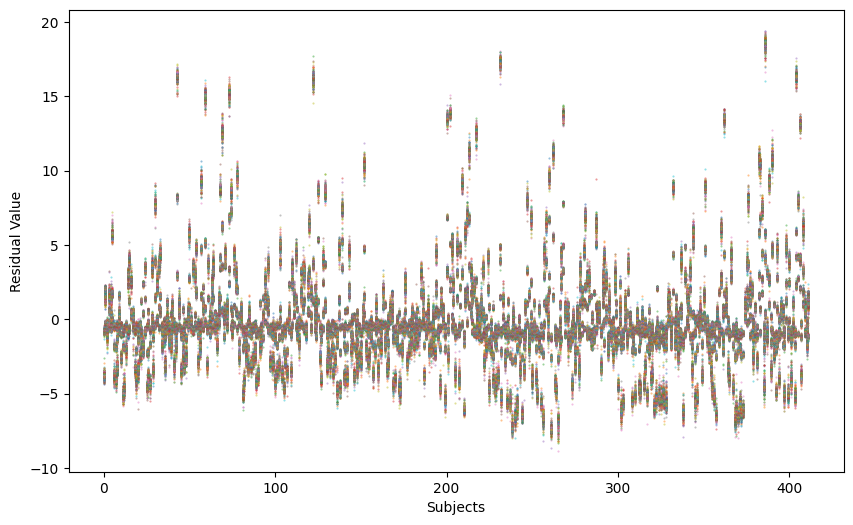

In [8]:
# plot a summary of the residuals distribution
# merged_df['residuals'][0] #= merged_df['residuals'].apply(lambda x: np.mean(x) if isinstance(x, np.ndarray) else x)
plt.figure(figsize=(10, 6))
for array in merged_df['residuals'].values:
    plt.plot(array, alpha=0.5, marker='o', linestyle='None', markersize=0.5)
# plt.title('Distribution of Residuals')
plt.xlabel('Subjects')
plt.ylabel('Residual Value')


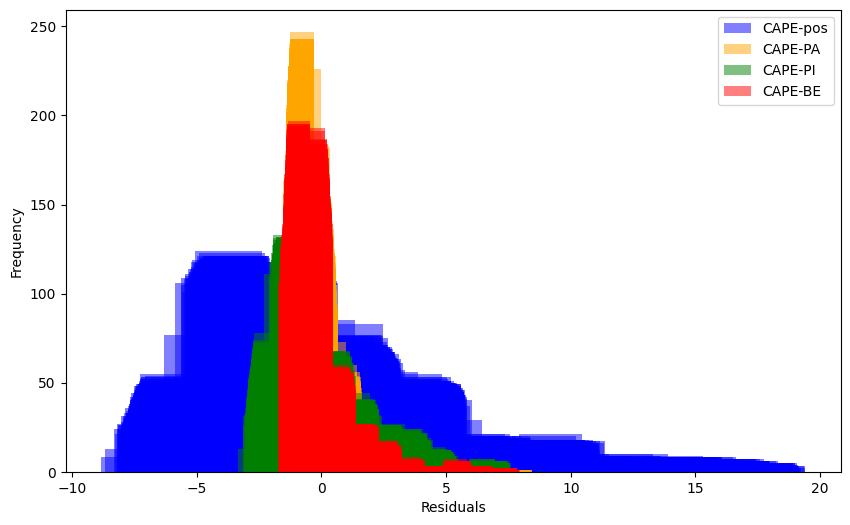

In [9]:
plt.figure(figsize=(10, 6))
# colapse all residuals of all data frames into a single array and plot the histogram
# add the label in only one of the histograms for each CAPE score
tot, pa, pi, be = False, False, False, False
for cape, array in zip(merged_df['CAPE'], merged_df['residuals'].values):
    
    if cape == 'cape_tot' and not tot:
        plt.hist(array, alpha=0.5, color='blue', label='CAPE-pos')
        tot = True
    elif cape == 'cape_tot':
        plt.hist(array, alpha=0.5, color='blue')
    elif cape == 'cape_PA_score' and not pa:
        plt.hist(array, alpha=0.5, color='orange', label='CAPE-PA')
        pa = True
    elif cape == 'cape_PA_score':
        plt.hist(array, alpha=0.5, color='orange')
    elif cape == 'cape_PI_score' and not pi:
        plt.hist(array, alpha=0.5, color='green', label='CAPE-PI')
        pi = True
    elif cape == 'cape_PI_score':
        plt.hist(array, alpha=0.5, color='green')
    elif cape == 'cape_BE_score' and not be:
        plt.hist(array, alpha=0.5, color='red', label='CAPE-BE')
        be = True
    elif cape == 'cape_BE_score':
        plt.hist(array, alpha=0.5, color='red')
plt.ylabel('Frequency')
plt.xlabel('Residuals')
plt.legend()

In [10]:
# calculate the effect size for the model of CAPE total score, DRPutamen and ROIs

def compute_mixedlm_r2(model):
    import numpy as np

    # -------------------------
    # 1. Extrair X (exog)
    # -------------------------
    X = None

    try:
        X = model.model.exog
    except Exception:
        try:
            X = model.exog
        except Exception:
            try:
                X = model.model.data.exog
            except Exception:
                raise ValueError("Não foi possível acessar a matriz de efeitos fixos (exog).")

    # -------------------------
    # 2. Extrair betas fixos
    # -------------------------
    try:
        beta = model.fe_params.values
    except Exception:
        try:
            beta = model.params.values
        except Exception:
            raise ValueError("Não foi possível acessar os coeficientes fixos.")

    # -------------------------
    # 3. Variância dos efeitos fixos
    # -------------------------
    fitted_fixed = X @ beta
    var_fixed = np.var(fitted_fixed)

    # -------------------------
    # 4. Variância dos efeitos aleatórios
    # -------------------------
    var_random = None

    # tentativa com cov_re
    try:
        cov_re = model.cov_re
        if cov_re is not None:
            var_random = float(np.trace(cov_re))
    except Exception:
        pass

    # fallback empírico
    if var_random is None:
        try:
            re_vals = []
            for v in model.random_effects.values():
                re_vals.append(list(v.values())[0])
            var_random = np.var(re_vals)
        except Exception:
            var_random = 0.0  # fallback extremo

    # -------------------------
    # 5. Variância residual
    # -------------------------
    try:
        var_resid = model.scale
    except Exception:
        try:
            var_resid = model.resid.var()
        except Exception:
            raise ValueError("Não foi possível acessar a variância residual.")

    # -------------------------
    # 6. R²
    # -------------------------
    total = var_fixed + var_random + var_resid

    r2_marginal = var_fixed / total
    r2_conditional = (var_fixed + var_random) / total

    return {
        "r2_marginal": r2_marginal,
        "r2_conditional": r2_conditional,
        "var_fixed": var_fixed,
        "var_random": var_random,
        "var_residual": var_resid
    }


cape_scores = ['cape_tot', 'cape_PA_score']
seed = 'DRPutamen'
significant_roi = [44,86]

for cape, roi in zip(cape_scores, significant_roi):
    model = smf.mixedlm( f'{cape} ~ roi_{roi} + age + C(gender) + abepscore + fd_mean_value + C(selection)', 
                                data=tmap_allsubj_organized[seed],
                                groups=tmap_allsubj_organized[seed]["colection_site"])
    fit = model.fit()

    # calculate standardized beta for the variable of interest (roi_44)
    std_beta = fit.params[f'roi_{roi}'] * (tmap_allsubj_organized[seed][f'roi_{roi}'].std() / tmap_allsubj_organized[seed][cape].std())
    print(f'Standardized Beta for {cape}, {seed}, roi_{roi}: {std_beta:.3f}')
    r2_results = compute_mixedlm_r2(fit)
    print(f"R² Marginal: {r2_results['r2_marginal']:.3f}")
    print(f"R² Conditional: {r2_results['r2_conditional']:.3f}")



Standardized Beta for cape_tot, DRPutamen, roi_44: -0.173
R² Marginal: 0.061
R² Conditional: 0.207
Standardized Beta for cape_PA_score, DRPutamen, roi_86: -0.200
R² Marginal: 0.082
R² Conditional: 0.097


In [11]:
# checking the effect of each covariate in the model for CAPE total score
covariates = ['age_c', 'C(gender)', 'abepscore', 'fd_mean_value', 'C(selection)']

tmap_allsubj_organized['DRPutamen']['age_c'] = tmap_allsubj_organized['DRPutamen']['age'] - tmap_allsubj_organized['DRPutamen']['age'].mean()

for VD in ['cape_tot','cape_PA_score','roi_44','roi_86']:
    for cov in covariates:
        model = smf.mixedlm(f'{VD} ~ {cov}',
                            data=tmap_allsubj_organized['DRPutamen'],
                            groups=tmap_allsubj_organized['DRPutamen']["colection_site"])
        fit = model.fit()
        print(f'--- {VD}: {cov} ---')
        print(fit.summary().tables[1])


--- cape_tot: age_c ---
            Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept   4.735    1.316   3.598  0.000   2.156  7.313
age_c      -0.144    0.246  -0.586  0.558  -0.626  0.338
Group Var   3.343    0.989                              
--- cape_tot: C(gender) ---
                Coef. Std.Err.      z  P>|z| [0.025 0.975]
Intercept       3.956    1.414  2.797  0.005  1.184  6.728
C(gender)[T.2]  1.614    0.484  3.338  0.001  0.666  2.562
Group Var       3.776    1.128                            
--- cape_tot: abepscore ---
            Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept   4.733    1.361   3.477  0.001   2.065   7.400
abepscore  -0.576    0.243  -2.373  0.018  -1.052  -0.100
Group Var   3.587    1.064                               
--- cape_tot: fd_mean_value ---
                Coef. Std.Err.       z  P>|z|   [0.025  0.975]
Intercept       4.784    1.561   3.064  0.002    1.724   7.845
fd_mean_value  -0.407    6.585  -0.062  0.951  -13.313  12.499
Gro

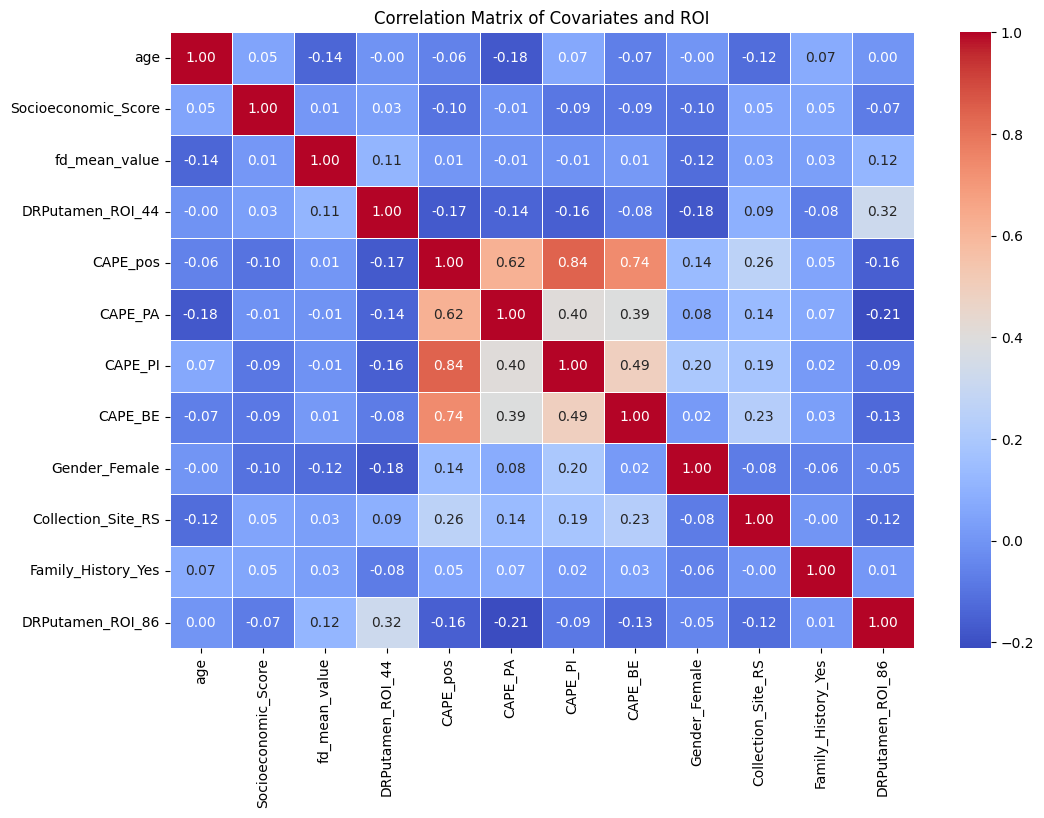

In [12]:
# Compute and visualize correlations between covariates
import matplotlib.pyplot as plt
import seaborn as sns

# Use the same fixed-effects structure as your mixed model
variables = ['age', 'gender', 'abepscore', 'colection_site', 'fd_mean_value', 'selection', 'roi_44']
model_data = tmap_allsubj_organized['DRPutamen'][variables + ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']].copy()

# One-hot encode categorical variables for correlation matrix and VIF diagnostics
model_data_encoded = pd.get_dummies(
    model_data,
    columns=['gender', 'colection_site', 'selection'],
    drop_first=True
)

# Make sure the target variables are present and the ROI variable is numeric
model_data_encoded['roi_44'] = tmap_allsubj_organized['DRPutamen']['roi_44']
model_data_encoded['roi_86'] = tmap_allsubj_organized['DRPutamen']['roi_86']

#rename columns for clarity
model_data_encoded.rename(columns={
    'cape_tot': 'CAPE_pos',
    'cape_PA_score': 'CAPE_PA',
    'cape_PI_score': 'CAPE_PI',
    'cape_BE_score': 'CAPE_BE',
    'roi_44': 'DRPutamen_ROI_44',
    'roi_86': 'DRPutamen_ROI_86',
    'selection_2': 'Family_History_Yes',
    'abepscore': 'Socioeconomic_Score',
    'gender_2': 'Gender_Female',
    'colection_site_2.0': 'Collection_Site_RS',
}, inplace=True)

corr_matrix = model_data_encoded.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Covariates and ROI')
plt.show()

In [13]:
import patsy
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Compute VIF and tolerance for the fixed effects of a mixedLM model.
# This uses the same design matrix as the mixed model, but it is a diagnostic
# for multicollinearity among the fixed effects only.

def compute_vif_tolerance(formula, data):
    # Build the fixed-effects design matrix from the same formula used in mixedlm
    _, X = patsy.dmatrices(formula, data, return_type='dataframe')

    # Remove the intercept for VIF calculation
    X = X.drop(columns=['Intercept'], errors='ignore')

    vif_values = []
    tolerance_values = []
    for i in range(X.shape[1]):
        vif_i = variance_inflation_factor(X.values, i)
        vif_values.append(vif_i)
        tolerance_values.append(1 / vif_i)

    vif_df = pd.DataFrame({
        'variable': X.columns,
        'VIF': vif_values,
        'Tolerance': tolerance_values,
    }).sort_values('VIF', ascending=False)

    return vif_df

# Example using your main model for one seed/ROI combination
for cape, roi in zip(['cape_tot', 'cape_PA_score'], [44, 86]):
    model_formula = f'{cape} ~ roi_{roi} + age + C(gender) + abepscore + fd_mean_value + C(selection)'
    data_for_vif = tmap_allsubj_organized['DRPutamen'].copy()

    vif_table = compute_vif_tolerance(model_formula, data_for_vif)
    print(vif_table,'\n')

# Interpretation guide
print('Interpretation:')
print('- VIF > 5: possible multicollinearity')
print('- VIF > 10: likely problematic multicollinearity')
print('- Tolerance < 0.2: possible problem')
print('- Tolerance < 0.1: likely problem')


            variable       VIF  Tolerance
5      fd_mean_value  2.721750   0.367411
1  C(selection)[T.2]  2.047924   0.488299
0     C(gender)[T.2]  1.779618   0.561918
2             roi_44  1.051835   0.950719
3                age  1.017587   0.982717
4          abepscore  1.016240   0.984020 

            variable       VIF  Tolerance
5      fd_mean_value  2.649635   0.377410
1  C(selection)[T.2]  2.028830   0.492895
0     C(gender)[T.2]  1.726376   0.579248
4          abepscore  1.022840   0.977670
3                age  1.017525   0.982777
2             roi_86  1.014122   0.986075 

Interpretation:
- VIF > 5: possible multicollinearity
- VIF > 10: likely problematic multicollinearity
- Tolerance < 0.2: possible problem
- Tolerance < 0.1: likely problem


In [ ]:
"""
Diagnostic suite for statsmodels MixedLM (random-intercept-only) models.

Usage:
    from mixedlm_diagnostics import run_diagnostics
    results = run_diagnostics(model, data=tmap_allsubj_organized[seed],
                               group_col="colection_site", outcome_col=cape)

Assumes `model` is a fitted result object from:
    smf.mixedlm(formula, data=..., groups=data["colection_site"]).fit()
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor


def run_diagnostics(model, data, group_col, outcome_col, fixed_formula=None,
                     continuous_predictors=None, categorical_predictors=None,
                     save_prefix=None):
    """
    model: fitted MixedLMResults
    data: dataframe used to fit the model (same rows, no NaNs in model vars)
    group_col: name of the grouping/clustering column (e.g. 'colection_site')
    outcome_col: name of the outcome variable
    fixed_formula: the fixed-effects formula string (for the OLS comparison model),
                   e.g. 'cape ~ roi_X + age + C(gender) + abepscore + fd_mean_value + C(selection)'
    continuous_predictors: list of continuous predictor column names for linearity checks
    categorical_predictors: list of categorical predictor column names for residual-by-group checks
    save_prefix: if given, saves each figure as f"{save_prefix}_<name>.png" instead of just showing
    """
    resid = model.resid
    fitted = model.fittedvalues
    out = {}

    def _save_or_show(fig, name):
        if save_prefix:
            fig.savefig(f"{save_prefix}_{name}.png", dpi=150, bbox_inches="tight")
            plt.close(fig)
        else:
            plt.show()

    # ---------- 1. Linearity ----------
    if continuous_predictors:
        n = len(continuous_predictors)
        fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
        axes = np.atleast_1d(axes)
        for ax, var in zip(axes, continuous_predictors):
            ax.scatter(data[var], resid, alpha=0.4, s=15)
            ax.axhline(0, color="red", linestyle="--")
            ax.set_xlabel(var)
            ax.set_ylabel("Residuals")
            ax.set_title(f"Residuals vs {var}")
        fig.tight_layout()
        _save_or_show(fig, "linearity")

    # ---------- 2. Normality of level-1 residuals ----------
    fig, ax = plt.subplots(figsize=(5, 5))
    stats.probplot(resid, dist="norm", plot=ax)
    ax.set_title("QQ plot: residuals")
    _save_or_show(fig, "qq_residuals")
    sw_stat, sw_p = stats.shapiro(resid) if len(resid) <= 5000 else (np.nan, np.nan)
    out["shapiro_residuals"] = {"stat": sw_stat, "p": sw_p}

    # ---------- 3. Normality of random effects (BLUPs) ----------
    re_vals = np.array([float(np.ravel(v)[0]) for v in model.random_effects.values()])
    fig, ax = plt.subplots(figsize=(5, 5))
    stats.probplot(re_vals, dist="norm", plot=ax)
    ax.set_title(f"QQ plot: random intercepts ({group_col}), n_groups={len(re_vals)}")
    _save_or_show(fig, "qq_random_effects")
    out["n_groups"] = len(re_vals)

    # ---------- 4. Homoscedasticity ----------
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(fitted, resid, alpha=0.4, s=15)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
    ax.set_title("Residuals vs Fitted")
    _save_or_show(fig, "resid_vs_fitted")

    X_bp = sm.add_constant(fitted)
    bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(resid, X_bp)
    out["breusch_pagan"] = {"lm_stat": bp_lm, "lm_p": bp_lm_p, "f_stat": bp_f, "f_p": bp_f_p}

    if categorical_predictors:
        fig, ax = plt.subplots(figsize=(6, 4))
        for var in categorical_predictors:
            fig, ax = plt.subplots(figsize=(6, 4))
            data.assign(_resid=resid).boxplot(column="_resid", by=var, ax=ax)
            ax.set_title(f"Residuals by {var}")
            plt.suptitle("")
            _save_or_show(fig, f"resid_by_{var}")

    # ---------- 5. Independence / clustering ----------
    group_var = float(model.cov_re.iloc[0, 0]) if hasattr(model.cov_re, "iloc") else float(model.cov_re[0][0])
    resid_var = float(model.scale)
    icc = group_var / (group_var + resid_var)
    out["icc"] = icc
    out["group_variance"] = group_var
    out["residual_variance"] = resid_var

    fig, ax = plt.subplots(figsize=(7, 4))
    data.assign(_resid=resid).boxplot(column="_resid", by=group_col, ax=ax)
    ax.set_title(f"Residuals by {group_col}")
    plt.suptitle("")
    plt.xticks(rotation=45)
    _save_or_show(fig, "resid_by_group")

    if fixed_formula:
        ols_model = smf.ols(fixed_formula, data=data).fit()
        llf_mixed = model.llf
        llf_ols = ols_model.llf
        lrt_stat = 2 * (llf_mixed - llf_ols)
        # boundary correction: mixture of chi2(0) and chi2(1) -> halve standard chi2(1) p-value
        p_standard = 1 - stats.chi2.cdf(lrt_stat, df=1)
        p_boundary = p_standard / 2
        out["lrt_vs_ols"] = {
            "lrt_stat": lrt_stat,
            "p_boundary_corrected": p_boundary,
            "note": "tests whether random intercept variance > 0"
        }

    # ---------- 6. Outliers / influence ----------
    std_resid = resid / resid.std()
    flagged = data.index[np.abs(std_resid) > 3]
    out["outliers_std_resid_gt3"] = list(flagged)

    # leave-one-group-out refit stability
    if fixed_formula:
        groups_unique = data[group_col].unique()
        coef_shifts = {}
        base_params = model.fe_params
        for g in groups_unique:
            sub = data[data[group_col] != g]
            try:
                m_sub = smf.mixedlm(fixed_formula, data=sub, groups=sub[group_col]).fit()
                shift = (m_sub.fe_params - base_params).abs()
                coef_shifts[g] = shift.to_dict()
            except Exception as e:
                coef_shifts[g] = {"error": str(e)}
        out["leave_one_group_out_shifts"] = coef_shifts

    # ---------- 7. Multicollinearity ----------
    X = model.model.exog
    exog_names = model.model.exog_names
    vif_vals = {}
    for i, name in enumerate(exog_names):
        try:
            vif_vals[name] = variance_inflation_factor(X, i)
        except Exception as e:
            vif_vals[name] = np.nan
    out["vif"] = vif_vals

    return out


def print_summary(results):
    """Pretty-print the key numbers from run_diagnostics output."""
    print("=== Normality ===")
    print(f"Shapiro-Wilk (residuals): stat={results['shapiro_residuals']['stat']:.4f}, "
          f"p={results['shapiro_residuals']['p']:.4f}")
    print(f"n groups (for random-effect QQ): {results['n_groups']}")

    print("\n=== Homoscedasticity ===")
    bp = results["breusch_pagan"]
    print(f"Breusch-Pagan: LM stat={bp['lm_stat']:.4f}, p={bp['lm_p']:.4f}")

    print("\n=== Independence / clustering ===")
    print(f"ICC (group variance share): {results['icc']:.4f}")
    print(f"Group variance: {results['group_variance']:.4f}, Residual variance: {results['residual_variance']:.4f}")
    if "lrt_vs_ols" in results:
        lrt = results["lrt_vs_ols"]
        print(f"LRT vs OLS (random intercept): stat={lrt['lrt_stat']:.4f}, "
              f"p(boundary-corrected)={lrt['p_boundary_corrected']:.4f}")

    print("\n=== Outliers ===")
    print(f"Observations with |std resid| > 3: {len(results['outliers_std_resid_gt3'])}")
    print(results["outliers_std_resid_gt3"])

    print("\n=== Multicollinearity (VIF) ===")
    for name, v in results["vif"].items():
        flag = "  <-- high" if isinstance(v, float) and v > 5 else ""
        print(f"{name}: {v:.2f}{flag}" if isinstance(v, float) else f"{name}: {v}")

----Diagnostics for cape_tot with ROI 44 completed and saved to D://second_level_results.---
=== Normality ===
Shapiro-Wilk (residuals): stat=0.9080, p=0.0000
n groups (for random-effect QQ): 2

=== Homoscedasticity ===
Breusch-Pagan: LM stat=11.5596, p=0.0007

=== Independence / clustering ===
ICC (group variance share): 0.1552
Group variance: 4.2338, Residual variance: 23.0536
LRT vs OLS (random intercept): stat=34.2041, p(boundary-corrected)=0.0000

=== Outliers ===
Observations with |std resid| > 3: 8
[43, 59, 73, 122, 202, 231, 386, 404]

=== Multicollinearity (VIF) ===
Intercept: 15.21  <-- high
C(gender)[T.2]: 1.06
C(selection)[T.2]: 1.02
roi_44: 1.05
age: 1.03
abepscore: 1.02
fd_mean_value: 1.05
----Diagnostics for cape_PA_score with ROI 86 completed and saved to D://second_level_results.---
=== Normality ===
Shapiro-Wilk (residuals): stat=0.7932, p=0.0000
n groups (for random-effect QQ): 2

=== Homoscedasticity ===
Breusch-Pagan: LM stat=26.7542, p=0.0000

=== Independence / c

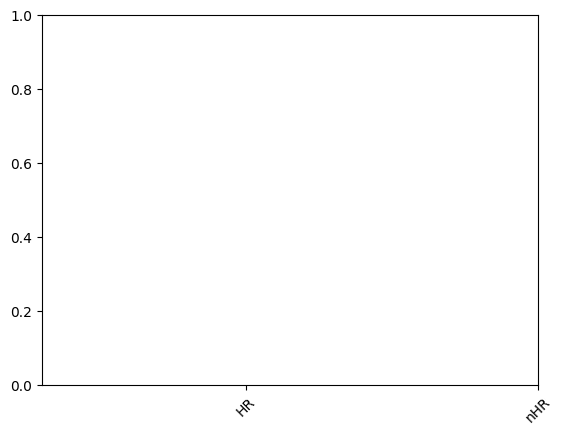

In [29]:
for cape, roi in zip(['cape_tot', 'cape_PA_score'], [44, 86]):
    model = smf.mixedlm( f'{cape} ~ roi_{roi} + age  + C(gender)  + abepscore + fd_mean_value + C(selection)', 
                            data=tmap_allsubj_organized['DRPutamen'], 
                            groups=tmap_allsubj_organized['DRPutamen']["colection_site"])
    fit = model.fit()

    run_diagnostics(
        model=fit,
        data=tmap_allsubj_organized['DRPutamen'],
        group_col="colection_site",
        outcome_col=f'{cape}',
        fixed_formula=f'{cape} ~ roi_{roi} + age + C(gender) + abepscore + fd_mean_value + C(selection)',
        continuous_predictors=[f'roi_{roi}', 'age', 'abepscore', 'fd_mean_value'],
        categorical_predictors=['gender', 'selection'],
        save_prefix=os.path.join(output, f'diagnostics_DRPutamen_{cape}')
    )
    print(f"----Diagnostics for {cape} with ROI {roi} completed and saved to {output}.---")
    print_summary(run_diagnostics(
            model=fit,
            data=tmap_allsubj_organized['DRPutamen'],
            group_col="colection_site",
            outcome_col=f'{cape}',
            fixed_formula=f'{cape} ~ roi_{roi} + age + C(gender) + abepscore + fd_mean_value + C(selection)',
            continuous_predictors=[f'roi_{roi}', 'age', 'abepscore', 'fd_mean_value'],
            categorical_predictors=['gender', 'selection'],
            save_prefix=os.path.join(output, f'diagnostics_DRPutamen_{cape}')
    ))